# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [34]:
df = pd.read_csv('hotels.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [35]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [36]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [37]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

first observance notes:
- refered and read thorugh thte dictionary
- target: is_canceled
- way more city hotel then resort hotel data. could cancellations be different between them?
- need to drop reservation_status before running so dont reveal teh answer of if was canceled before the model can determin itsself
- some importnat valibrels i think are gonna say alot adr, lead time, deposit type, previous cancellations
- need to drop agent and company cause mostly null
- country has soooo many unquie values. is there a way to group these countrys into smaller groups to one hot encode easier
- adr has really big range so thease features are gonna need to be standarized




In [38]:
# Calculate prevalence of the target value, how hard of problem is this going to be?
prevalence = (df['is_canceled'] == 1).sum() / len(df) #target / total
prevalence

np.float64(0.37041628277075134)

37% of bookings were canceled
this shouldn't be too hard bc the data is pretty balanced. 
theres enough examples of both classes for the model to learn from.

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [39]:
# Check for missing data and drop features with too many missing values, there are some. 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [40]:
# need to drop agent and company cause mostly null
df.drop(columns=['agent', 'company'], inplace=True)
#drop any rows with missing values
#this is fine becuase teh dataset is really big so dropping these couple of rows wont make much impacts
df = df.dropna()

In [41]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

#the reservation status say the answer tot eh question of is the customer canceld or not so need to drop them
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [42]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

In [43]:
# there are 177 unquie values for country. if you one hot encode all of tehse its just gonna so big and so many columns
# my strategy is to use the help of an llm to categorise these into there spesfic regions to only get a handful of unique values and then one hot encode those.
#list out every unquie value to give to llm
print(sorted(df['country'].dropna().unique()))

['ABW', 'AGO', 'AIA', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATA', 'ATF', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BOL', 'BRA', 'BRB', 'BWA', 'CAF', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'CN', 'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYM', 'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FRA', 'FRO', 'GAB', 'GBR', 'GEO', 'GGY', 'GHA', 'GIB', 'GLP', 'GNB', 'GRC', 'GTM', 'GUY', 'HKG', 'HND', 'HRV', 'HUN', 'IDN', 'IMN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JEY', 'JOR', 'JPN', 'KAZ', 'KEN', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBY', 'LCA', 'LIE', 'LKA', 'LTU', 'LUX', 'LVA', 'MAC', 'MAR', 'MCO', 'MDG', 'MDV', 'MEX', 'MKD', 'MLI', 'MLT', 'MMR', 'MNE', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'MYT', 'NAM', 'NCL', 'NGA', 'NIC', 'NLD', 'NOR', 'NPL', 'NZL', 'OMN', 'PAK', 'PAN', 'PER', 'PHL', 'PLW', 'POL', 'PRI', 'PRT', 'PRY', 'PYF', 'QAT', 'ROU', 'RUS', 'RWA', 'SAU',

In [44]:
# llm makes groups of the new categoires based on there geographic locations
europe_list = ['ALB', 'AND', 'AUT', 'BEL', 'BGR', 'BIH', 'BLR', 'CHE', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'FRO', 'GBR', 'GEO', 'GGY', 'GIB', 'GRC', 'HRV', 'HUN', 'IMN', 'IRL', 'ISL', 'ITA', 'JEY', 'LIE', 'LTU', 'LUX', 'LVA', 'MCO', 'MKD', 'MLT', 'MNE', 'NLD', 'NOR', 'POL', 'ROU', 'RUS', 'SMR', 'SRB', 'SVK', 'SVN', 'SWE', 'UKR']
americas_list = ['ABW', 'AIA', 'ARG', 'BHS', 'BOL', 'BRA', 'BRB', 'CAN', 'CHL', 'COL', 'CRI', 'CUB', 'CYM', 'DMA', 'DOM', 'ECU', 'GTM', 'GUY', 'HND', 'JAM', 'KNA', 'LCA', 'MEX', 'NIC', 'PAN', 'PER', 'PRI', 'PRY', 'SLV', 'SUR', 'URY', 'USA', 'VEN', 'VGB']
asia_list = ['ARE', 'ARM', 'AZE', 'BGD', 'BHR', 'CHN', 'CN', 'HKG', 'IDN', 'IND', 'IRN', 'IRQ', 'ISR', 'JOR', 'JPN', 'KAZ', 'KHM', 'KOR', 'KWT', 'LAO', 'LBN', 'LKA', 'MAC', 'MDV', 'MMR', 'MYS', 'NPL', 'OMN', 'PAK', 'PHL', 'QAT', 'SAU', 'SGP', 'SYR', 'THA', 'TJK', 'TMP', 'TUR', 'TWN', 'UZB', 'VNM']
africa_list = ['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COM', 'CPV', 'DJI', 'DZA', 'EGY', 'ETH', 'GAB', 'GHA', 'GNB', 'KEN', 'LBY', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYT', 'NAM', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'STP', 'SYC', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']
oceania_list = ['ASM', 'AUS', 'FJI', 'KIR', 'NCL', 'NZL', 'PLW', 'PYF']

In [45]:
#make loop to sort thought the codes and make new column with the new categories calling the assiments above
def get_region(country_code):
    if country_code == 'PRT':
        return 'Portugal'
    elif country_code in europe_list:
        return 'Europe'
    elif country_code in americas_list:
        return 'Americas'
    elif country_code in asia_list:
        return 'Asia'
    elif country_code in africa_list:
        return 'Africa'
    elif country_code in oceania_list:
        return 'Oceania'
    else:
        return 'Other'

In [46]:
# make new col of the new categories calling the map dictionary
df['country_region'] = df['country'].apply(get_region)

# drop the original country column so theres no duplicates
df = df.drop(columns=['country'])

# check new column and the value counts to see how many of each category there is
print(df['country_region'].value_counts())

country_region
Europe      59309
Portugal    48586
Americas     4980
Asia         4398
Africa       1113
Oceania       506
Other           6
Name: count, dtype: int64


In [47]:
# now make the numeric and categorical features list for the pipeline
NUMERIC = [
    'lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 
    'babies', 'is_repeated_guest', 'previous_cancellations', 
    'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 
    'adr', 'required_car_parking_spaces', 'total_of_special_requests'
]
CATEGORICAL = [
    'hotel', 'arrival_date_month', 'meal', 'country_region', # new country region instead of country
    'market_segment', 'distribution_channel', 'reserved_room_type', 
    'assigned_room_type', 'deposit_type', 'customer_type'
]
TARGET = 'is_canceled'

In [48]:
#split testing and training data
X = df[CATEGORICAL + NUMERIC]
y = df[TARGET]

# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) # stratify=y makes sure both splits have roughly the 
#same 37/63 cancellation ratio or else the test set could have way more or fewer cancellations than normal.

In [49]:
# sklearn Pipeline
# bacially just defining to be used later  so dont have to manually do the one hot encoding and scaling each time to make a model
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', #handle_unknown='ignore' is just a safety net for when the model sees a category 
    # in new data that it never saw during training. instead of crashing it just 
    # gives that row all zeros for that feature and then keeps going
                           sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # min max over standard scaler
])

---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [50]:
model_1 = Pipeline([
    ('preprocessor', preprocessor),  # the ColumnTransformer built above
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=200))
])
model_1.fit(X_train, y_train) #run model on trinaing

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

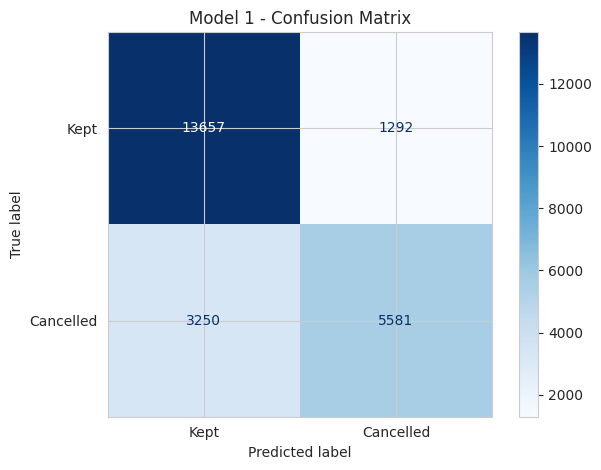

In [51]:
y_pred_m1 = model_1.predict(X_test) #run model on testing data to get predictions
cm_m1 = confusion_matrix(y_test, y_pred_m1) #compare the predicitons to the actual values in the test set to get the confusion matrix
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Kept', 'Cancelled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 - Confusion Matrix')
plt.tight_layout()
plt.show()

In [52]:
# print the classification report of the actual and predicted values on the test set 
print(classification_report(y_test, y_pred_m1, target_names=['Kept', 'Canceled']))

              precision    recall  f1-score   support

        Kept       0.81      0.91      0.86     14949
    Canceled       0.81      0.63      0.71      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.77      0.78     23780
weighted avg       0.81      0.81      0.80     23780



AUC score: 0.89060


/tmp/ipykernel_2254/1027733291.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-." (-> color='k'). The keyword argument will take precedence.
  plt.plot([0,1],[0,1], 'k-.', color='red')


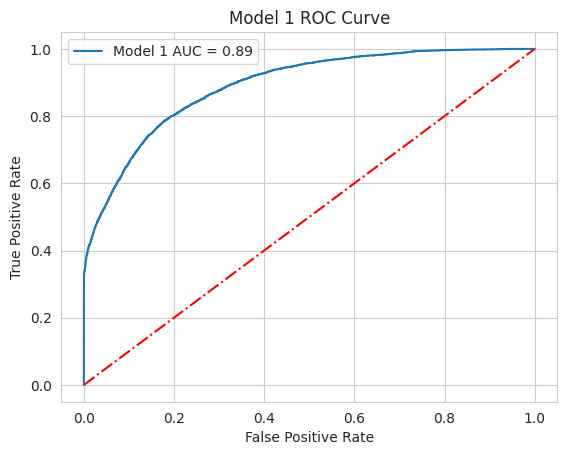

In [53]:
y_prob_m1 = model_1.predict_proba(X_test)[:, 1]  # probability of being cancelled 
#bascially a confidence score for how likely the model thinks the customer is to cancel.

fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_prob_m1)
auc_m1 = roc_auc_score(y_test, y_prob_m1)
print(f'AUC score: {auc_m1:.5f}')

plt.plot(fpr_m1, tpr_m1, label=f'Model 1 AUC = {auc_m1:.2f}')
plt.plot([0,1],[0,1], 'k-.', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 1 ROC Curve')
plt.legend()
plt.show()

Model 1 got an AUC of 0.89 which is pretty good for a baseline. Theres still apretyy high number of false negatives at 3250. This means that those customers that the model predicted would not actually cancel but actually did cancel. this is bad beucase then the hotel would be behind adn miss out on stopping those cancellations with insentives if they knew. thse are the most costly so while the model still did pretty good at predicting the cancellations it still needs t be imrpoved.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



### liblinear:

In [54]:
model_2_lib = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=200))
])
model_2_lib.fit(X_train, y_train) #run model on trinaing

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

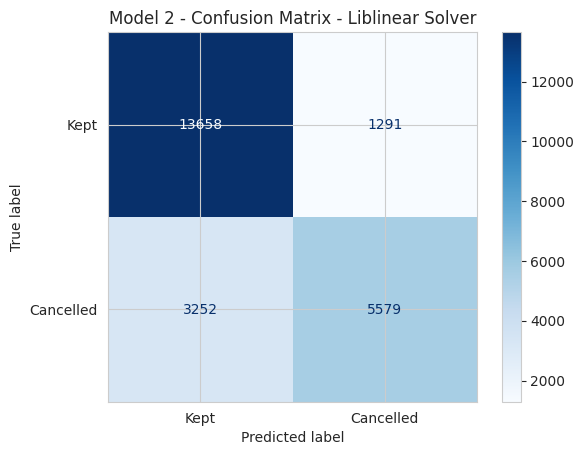

AUC score: 0.89067


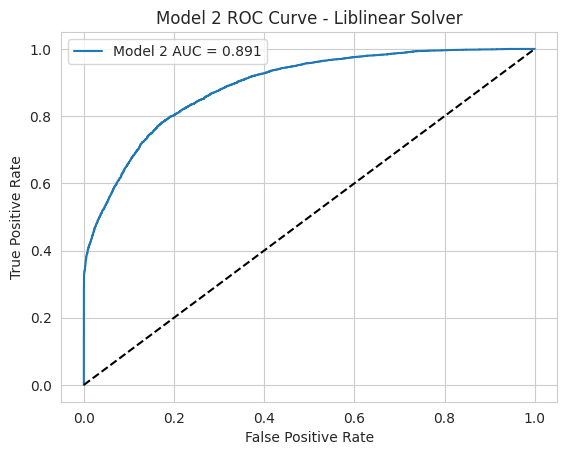

In [55]:
#use same methodsa as above to show confustion and auc for the new model

# confusion matrix
y_pred_m2 = model_2_lib.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Kept', 'Cancelled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 - Confusion Matrix - Liblinear Solver')
plt.show()

# ROC/AUC
y_prob_m2 = model_2_lib.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, _ = roc_curve(y_test, y_prob_m2)
auc_m2 = roc_auc_score(y_test, y_prob_m2)
print(f'AUC score: {auc_m2:.5f}')

plt.plot(fpr_m2, tpr_m2, label=f'Model 2 AUC = {auc_m2:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 2 ROC Curve - Liblinear Solver')
plt.legend()
plt.show()

### saga:

In [56]:
model_2_saga = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', max_iter=200))
])
model_2_saga.fit(X_train, y_train) #run model on trinaing

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

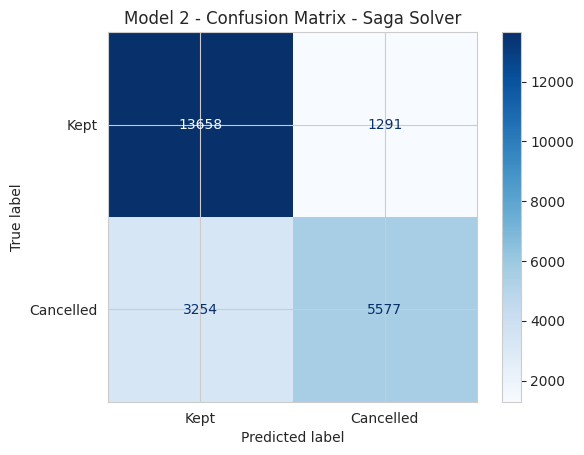

AUC score: 0.89068


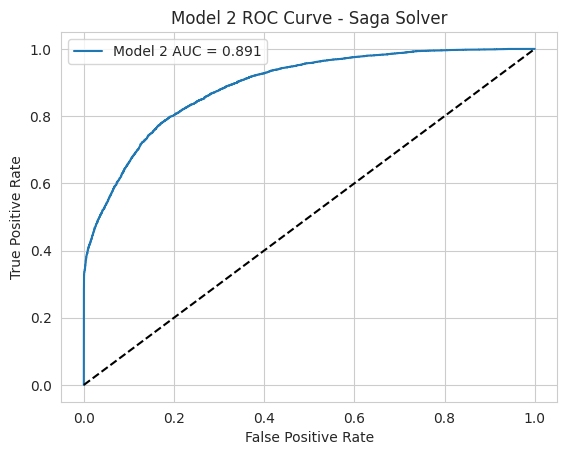

In [57]:
#use same methods as before to show confustion and auc for the new model

# confusion matrix
y_pred_m2 = model_2_saga.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Kept', 'Cancelled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 - Confusion Matrix - Saga Solver')
plt.show()

# ROC/AUC
y_prob_m2 = model_2_saga.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, _ = roc_curve(y_test, y_prob_m2)
auc_m2 = roc_auc_score(y_test, y_prob_m2)
print(f'AUC score: {auc_m2:.5f}')

plt.plot(fpr_m2, tpr_m2, label=f'Model 2 AUC = {auc_m2:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 2 ROC Curve - Saga Solver')
plt.legend()
plt.show()

tried both liblinear (AUC 0.89067) and saga (AUC 0.89068) solvers. The liblinear has 2 less false positve cases but the saga has a higher AUC score. Still though the differences are not that much between all solvers even from model 1 AUC scores are all very very close and similar. for model 3 though im going to go with saga since its more for bigger datasets

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [58]:
#got warning about iteration number at 200 so cahnged to 1000

### balanced w/ 5 folds:

In [59]:
# build pipeline with balanced class weight from best solver which i think 
# was saga ebcuase it had a higher auc score 
model_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', max_iter=1000, class_weight='balanced'))
])

In [60]:
cv_scores = cross_val_score(model_3, X_train, y_train, cv=5, scoring='roc_auc')
# use 'roc_auc' over 'accuracy' bc the classes are imbalanced with 63/37 split 
# and it measeaures how well the model can separate the two classes across all 
# possible thresholds rather than just at a single threshold like accuracy does.
print("CV AUC scores:", cv_scores)
print("CV AUC Average Score:", cv_scores.mean())

CV AUC scores: [0.88981281 0.88516352 0.88874799 0.88515078 0.88690355]
CV AUC Average Score: 0.8871557300168196


In [61]:
# now fit on full training set and evaluate on test set
model_3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

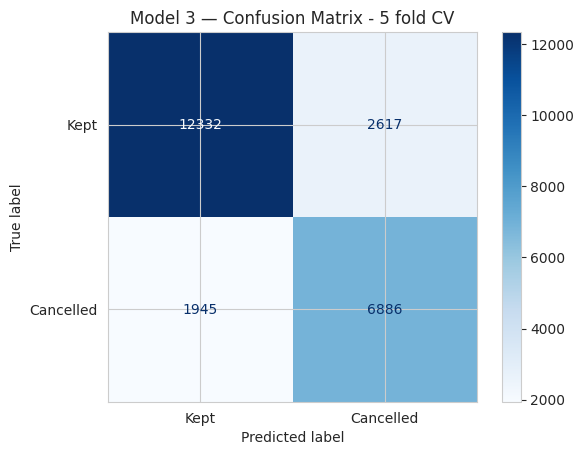

AUC score: 0.89130


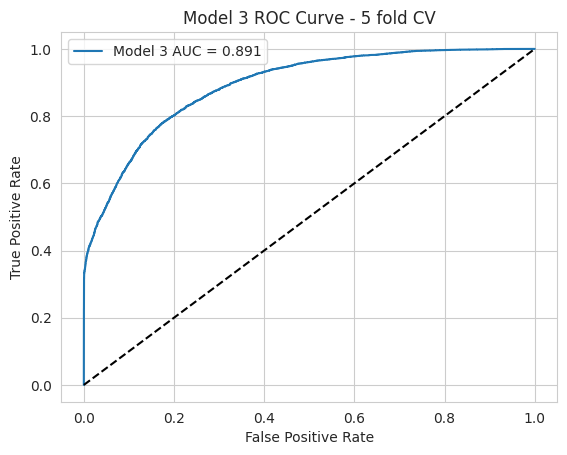

In [62]:
# confusion matrix
y_pred_m3 = model_3.predict(X_test)
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Kept', 'Cancelled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix - 5 fold CV')
plt.show()

# ROC/AUC
y_prob_m3 = model_3.predict_proba(X_test)[:, 1]
fpr_m3, tpr_m3, _ = roc_curve(y_test, y_prob_m3)
auc_m3 = roc_auc_score(y_test, y_prob_m3)
print(f'AUC score: {auc_m3:.5f}')

plt.plot(fpr_m3, tpr_m3, label=f'Model 3 AUC = {auc_m3:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 3 ROC Curve - 5 fold CV')
plt.legend()
plt.show()

### balanced w/ 10 folds:

In [63]:
cv_scores = cross_val_score(model_3, X_train, y_train, cv=10, scoring='roc_auc')
# use 'roc_auc' over 'accuracy' bc the classes are imbalanced with 63/37 split 
# and it measeaures how well the model can separate the two classes across all 
# possible thresholds rather than just at a single threshold like accuracy does.
print("CV AUC scores:", cv_scores)
print("CV AUC Average Score:", cv_scores.mean())

CV AUC scores: [0.88955122 0.89075535 0.88420447 0.88612303 0.88989199 0.8888475
 0.88761758 0.88329066 0.88773722 0.88603534]
CV AUC Average Score: 0.8874054372077946


In [64]:
# remove class_weight to see what happens to recall
model_3_unbalanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', max_iter=1000))
])
model_3_unbalanced.fit(X_train, y_train)
y_pred_unbalanced = model_3_unbalanced.predict(X_test)

print("WITHOUT balanced:")
print(classification_report(y_test, y_pred_unbalanced, target_names=['Kept', 'Cancelled']))
print("WITH balanced:")
print(classification_report(y_test, y_pred_m3, target_names=['Kept', 'Cancelled']))

WITHOUT balanced:
              precision    recall  f1-score   support

        Kept       0.81      0.91      0.86     14949
   Cancelled       0.81      0.63      0.71      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.77      0.78     23780
weighted avg       0.81      0.81      0.80     23780

WITH balanced:
              precision    recall  f1-score   support

        Kept       0.86      0.82      0.84     14949
   Cancelled       0.72      0.78      0.75      8831

    accuracy                           0.81     23780
   macro avg       0.79      0.80      0.80     23780
weighted avg       0.81      0.81      0.81     23780



the 5 fold mean AUC was 0.8872 and the 10 fold mean AUC was 0.8874 so there basically 
identical but the more folds gives it a more stable estimate but doesn't really change the actual result. the big finding is in the class_weight experiment becasue without balanced the recall on cancelled was 0.63 meaning that 37% of cancellations were missed while 
with the balanced it went to 0.78. but theres a tradeoff cause the cancelled dropped from 
0.81 to 0.72 which meant theres more false alarms, but for the hotel when missing a real cancellation it is way more expensive than wrongly flagging someone who ends up showing up anyway.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)



To predict hotel cancellations i built three logistic regression models, each one improving on the last. the main challenge with this problem is trying to minimize the false negatives because those are the cases where the model predicts a guest will show up but they actually cancel. In the hotel context that's the most expensive mistake because the room sits empty with no chance to resell it or reach out with an incentive to keep the booking. to tackle this i used class_weight='balanced' in model 3 which tells the model to pay extra attention to cancellations during training since they're the minority class at 37%. i also used cross validation to make sure the performance score was reliable and not just a fluke of one round of a lucky train/test split by training and testing across 5 different folds and averaging the results to get a much more trustworthy estimate of how the model would actually do on the new data.

Model 3 ended up being the best choice for this problem. while all three models had similar AUC scores around 0.89 which means they're all equally good at ranking cancellations above non-cancellations overall, but model 3 caught way more real cancellations as recall on the cancelled class increased from 0.63 to 0.78 compared to models 1 and 2. that means it went from missing 37% of cancellations down to only missing 22% which is really good and worth it even if the tradeoff is slightly more false alarm (guests flagged as likely to cancel who actually show up) becasue but for a hotel it's a much cheaper mistake than an empty room. i'd recommend deploying model 3 to flag high risk bookings early so the team can proactively reach out with incentives to keep those guests from canceling.

--- 

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 


In [69]:
model = Pipeline(steps=[
    ('prep', preprocessor), 
    ('model', LogisticRegression(max_iter=5000, random_state=42, solver='liblinear', l1_ratio=1))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [72]:
# 1
#define a grid of C values to search over
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

#ese GridSearchCV to perform 5-fold cross-validation
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [73]:
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'model__C': 100}
0.892108961494257


I tested C values of 0.001, 0.01, 0.1, 1, 10, and 100. The best value was 100 that produced a cross validation AUC of 0.8921. This is only a very small improvement over the original model, so changing C did not make a major difference.